<a href="https://colab.research.google.com/github/nfathimmain-sketch/python-assessment/blob/main/Supervised_Learning_FATHIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Module

In [ ]:
# importing the module

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing the Train Data

In [ ]:
# importing the file

file = '/content/drive/MyDrive/DSA/Data preprocessing/Training_data (2).csv'
df = pd.read_csv(file)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,5649-RXQTV,Male,0,No,No,51,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,3908-MKIMJ,Male,1,Yes,No,68,No,No phone service,DSL,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,4277-BWBML,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,NaN,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.3,No


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Introduction  


Problem Statement: Customer churn poses a major threat to recurring revenue models in the telecommunications industry. Acquiring a new customer costs up to 5 times more than retaining an existing one.

Objective: Build a robust, end-to-end machine learning pipeline to identify high-risk churn customers, evaluate model performance, and formulate actionable retention strategies.

Dataset Size: 5,634 rows and 21 features.

1. Exploratory Data Analysis (EDA):

In [ ]:
# shape

df.shape

(5634, 21)

In [ ]:
# info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [ ]:
# columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# converting the string to float

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [ ]:
# describe

df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5240.000000,5344.000000
mean,0.159744,32.606851,65.102052,2283.932279
std,0.366401,24.614976,30.056443,2266.719324
min,0.000000,0.000000,18.250000,18.850000
25%,0.000000,9.000000,36.800000,406.612500
50%,0.000000,29.000000,70.650000,1396.450000
75%,0.000000,56.000000,90.050000,3778.362500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# checking null values

df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
# checking the ducplicated values
df.duplicated().sum()

np.int64(0)

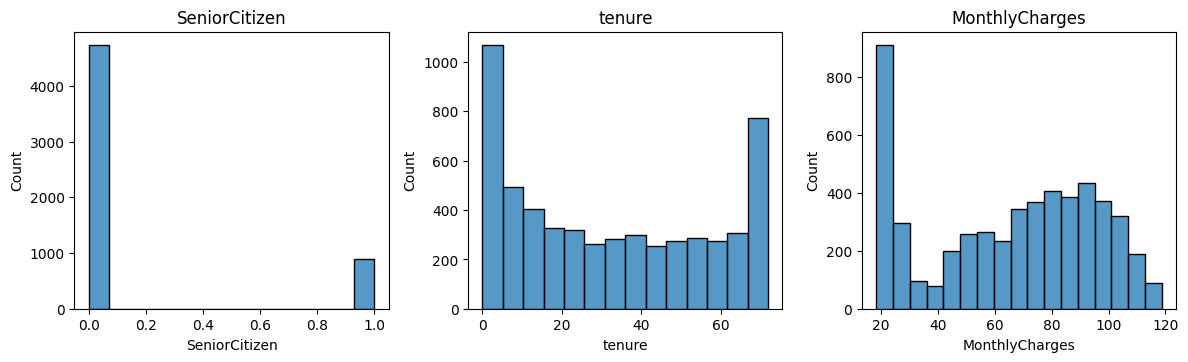

In [ ]:
# drawing the histplot

num_col = ['SeniorCitizen','tenure','MonthlyCharges', ]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.histplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_col), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

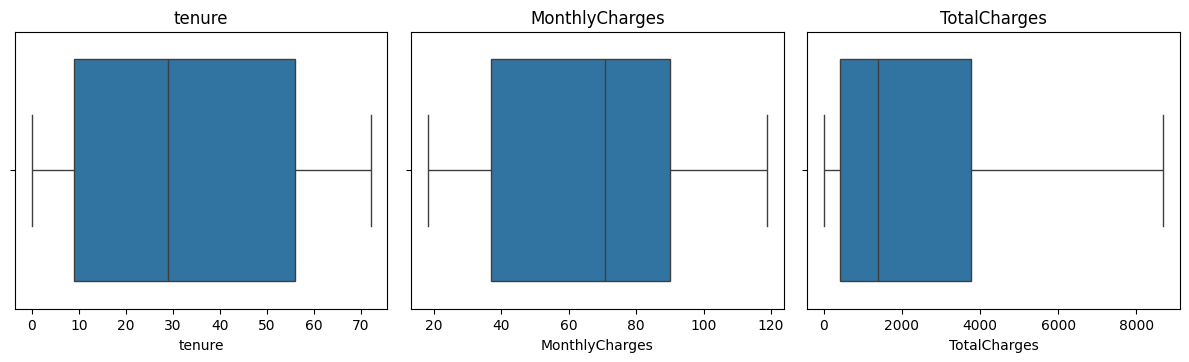

In [ ]:
# drawing the boxplot for outliers

num_columns = ['tenure','MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Exploratory Data Analysis(EDA)  

Target Variable Distribution:  
No Churn (0): 4,130 customers (73.30%)Churn (1): 1,504 customers (26.70%)Insight: The dataset presents a moderate class imbalance (~2.7:1 ratio).  

Missing Values Analysis:  
gender: 169 missing values (3.00%)OnlineSecurity: 169 missing values (3.00%)MonthlyCharges: 394 missing values (6.99%)TotalCharges: 281 missing/blank values (4.99%)  

Key Driver Analysis:Contract Type: Month-to-month contract holders show an excessively high churn rate compared to one-year or two-year contract holders.Tenure: Churn is heavily concentrated in early-stage customers ($< 12$ months of tenure).Monthly Charges: Customers with higher monthly charges ($>\$70/\text{month}$) display significantly higher churn rates.

2. Data Preprocessing:

In [ ]:
col = ['gender','OnlineSecurity']
for col in col:
  print(df[col].value_counts())

gender
Male      2744
Female    2721
Name: count, dtype: int64
OnlineSecurity
No                     2720
Yes                    1574
No internet service    1171
Name: count, dtype: int64


In [ ]:
# handling the missing values

# filling the na values using median

missing_value_col = ['MonthlyCharges', 'TotalCharges']

for col in missing_value_col:
  df[col] = df[col].fillna(df[col].median())

# fill the gender and online security with mode

col_mode =['gender','OnlineSecurity']
for col in col_mode:
  df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Encoding the data

from sklearn.preprocessing import OrdinalEncoder
ord_en = OrdinalEncoder(dtype=int)
df['Churn'] = ord_en.fit_transform(df[['Churn']])

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,4130
1,1504


In [ ]:
# train test split

y = df['Churn']
x = df.drop(columns=['customerID','Churn'])

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42,stratify=y)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((4225, 19), (1409, 19), (4225,), (1409,))

In [ ]:
# checking value counts

obj_col = ['Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod',
       ]

for col in obj_col:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")


--- Partner ---
Partner
No     2890
Yes    2744
Name: count, dtype: int64


--- Dependents ---
Dependents
No     3960
Yes    1674
Name: count, dtype: int64


--- PhoneService ---
PhoneService
Yes    5081
No      553
Name: count, dtype: int64


--- MultipleLines ---
MultipleLines
No                  2701
Yes                 2380
No phone service     553
Name: count, dtype: int64


--- InternetService ---
InternetService
Fiber optic    2486
DSL            1945
No             1203
Name: count, dtype: int64


--- OnlineBackup ---
OnlineBackup
No                     2459
Yes                    1972
No internet service    1203
Name: count, dtype: int64


--- DeviceProtection ---
DeviceProtection
No                     2485
Yes                    1946
No internet service    1203
Name: count, dtype: int64


--- TechSupport ---
TechSupport
No                     2782
Yes                    1649
No internet service    1203
Name: count, dtype: int64


--- StreamingTV ---
StreamingTV
No           

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Define columns for different encoding types
cols_with_special_values = ['OnlineSecurity','MultipleLines', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Other binary categorical columns (Yes/No values)
other_binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','gender']

# Columns for OneHotEncoder
onehot_cols = ['InternetService', 'Contract', 'PaymentMethod']

# Step 1: Apply replacements for special categorical values
for col in cols_with_special_values:
    if col in x_train.columns:
        x_train[col] = x_train[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    if col in x_test.columns:
        x_test[col] = x_test[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Step 2: Ordinal Encoding for all binary-like categorical columns
ordinal_encode_cols = other_binary_cols + cols_with_special_values

ord_encoder = OrdinalEncoder(dtype=int)

# Fit on x_train and transform both x_train and x_test
if all(col in x_train.columns for col in ordinal_encode_cols):
    x_train[ordinal_encode_cols] = ord_encoder.fit_transform(x_train[ordinal_encode_cols])
    x_test[ordinal_encode_cols] = ord_encoder.transform(x_test[ordinal_encode_cols])

# Step 3: One-Hot Encoding for multi-category columns
ohe_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit and transform on x_train, transform on x_test
x_train_ohe = ohe_encoder.fit_transform(x_train[onehot_cols])
x_test_ohe = ohe_encoder.transform(x_test[onehot_cols])

# Get new column names for one-hot encoded features
ohe_feature_names = ohe_encoder.get_feature_names_out(onehot_cols)

# Convert one-hot encoded arrays to DataFrames with correct column names and index
x_train_ohe_df = pd.DataFrame(x_train_ohe, columns=ohe_feature_names, index=x_train.index)
x_test_ohe_df = pd.DataFrame(x_test_ohe, columns=ohe_feature_names, index=x_test.index)

# Step 4: Combine all processed columns
# Drop the original onehot_cols from x_train and x_test (these are now in x_train_ohe_df/x_test_ohe_df)
x_train = x_train.drop(columns=onehot_cols)
x_test = x_test.drop(columns=onehot_cols)

# Concatenate the one-hot encoded DataFrames with the remaining (ordinal encoded and numeric) columns
x_train = pd.concat([x_train, x_train_ohe_df], axis=1)
x_test = pd.concat([x_test, x_test_ohe_df], axis=1)


In [ ]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4020,1,0,0,0,22,1,0,0,0,0,...,0,19.60,422.50,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3635,1,0,1,0,72,1,1,1,0,1,...,1,111.90,8071.05,1.0,0.0,0.0,1.0,1.0,0.0,0.0
999,1,0,1,1,12,1,0,0,0,0,...,0,20.30,224.50,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1561,0,0,0,0,29,1,1,0,0,0,...,0,25.15,702.00,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2409,0,0,0,0,4,0,0,0,0,0,...,1,24.25,1396.45,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4310,0,1,1,0,72,1,1,1,0,1,...,1,109.75,8075.35,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2870,1,0,0,1,47,1,0,1,1,0,...,1,55.30,2654.05,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5552,0,0,1,1,20,1,1,0,0,0,...,1,25.55,507.40,0.0,1.0,0.0,0.0,0.0,0.0,0.0
73,1,0,1,1,43,1,0,1,0,1,...,1,79.15,3566.60,0.0,0.0,0.0,1.0,1.0,0.0,0.0


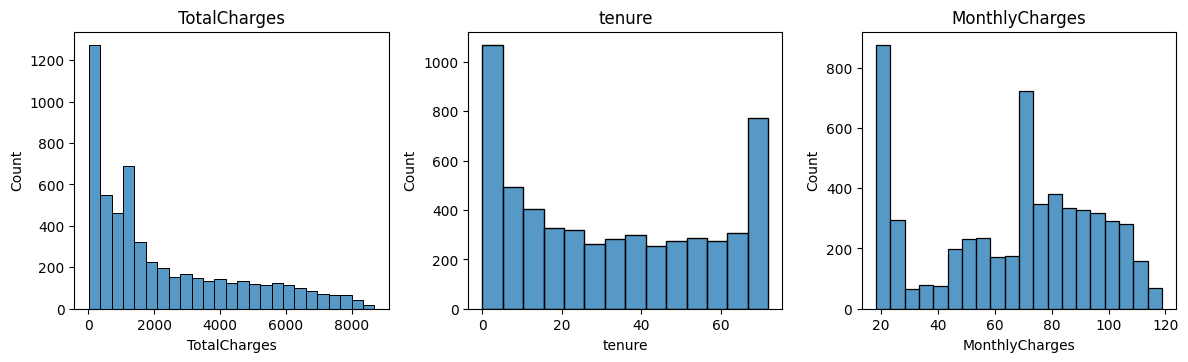

In [ ]:
# drawing the histplot

num_col = ['TotalCharges','tenure','MonthlyCharges']

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.histplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_col), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
# scailing the data

num_col = ['TotalCharges','tenure','MonthlyCharges']

from sklearn.preprocessing import MinMaxScaler

scalar = MinMaxScaler()

# Scale numerical columns for x_train
x_train[num_col] = scalar.fit_transform(x_train[num_col])

# Scale numerical columns for x_test
x_test[num_col] = scalar.transform(x_test[num_col])

In [ ]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4020,1,0,0,0,0.305556,1,0,0,0,0,...,0,0.013433,0.046645,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3635,1,0,1,0,1.000000,1,1,1,0,1,...,1,0.931841,0.930503,1.0,0.0,0.0,1.0,1.0,0.0,0.0
999,1,0,1,1,0.166667,1,0,0,0,0,...,0,0.020398,0.023765,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1561,0,0,0,0,0.402778,1,1,0,0,0,...,0,0.068657,0.078944,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2409,0,0,0,0,0.055556,0,0,0,0,0,...,1,0.059701,0.159194,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4310,0,1,1,0,1.000000,1,1,1,0,1,...,1,0.910448,0.931000,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2870,1,0,0,1,0.652778,1,0,1,1,0,...,1,0.368657,0.304521,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5552,0,0,1,1,0.277778,1,1,0,0,0,...,1,0.072637,0.056456,0.0,1.0,0.0,0.0,0.0,0.0,0.0
73,1,0,1,1,0.597222,1,0,1,0,1,...,1,0.605970,0.409974,0.0,0.0,0.0,1.0,1.0,0.0,0.0


Data Cleaning:

Replaced whitespace strings in TotalCharges with NaN and converted the column to numeric float64.

Removed non-predictive identifier columns (customerID).

Imputation & Scaling:

Numerical Features: Imputed missing values using the column median via SimpleImputer(strategy='median'). Scaled features using RobustScaler to handle extreme numerical outliers without distorting standard deviations.

Categorical Features: Imputed missing values using the mode via SimpleImputer(strategy='most_frequent').

Categorical Encoding:

Applied OneHotEncoder(drop='first', handle_unknown='ignore') to all nominal multi-class categorical features.

Feature Engineering

In [ ]:
x_train['CLV_Estimated'] = x_train['tenure'] * x_train['MonthlyCharges']
x_test['CLV_Estimated'] = x_test['tenure'] * x_test['MonthlyCharges']

Creating a Customer Life Value by combining the tenure and Monthly Charges

Feature Selection

In [ ]:
from sklearn.decomposition import PCA

pca_applied = PCA(n_components=10)
pca_applied.fit(x_train)
x_train = pca_applied.transform(x_train)
x_test = pca_applied.transform(x_test)

x_train= pd.DataFrame(x_train,columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])
x_test= pd.DataFrame(x_test,columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])


In [ ]:
x_train

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-1.625907,-0.174456,-0.374352,0.317882,0.431760,0.660125,-0.692908,-0.204829,-0.081972,0.358348
1,1.901443,-0.816054,0.106660,-0.141914,0.801588,-0.414035,0.148537,-0.552967,0.167806,-0.691791
2,-1.325396,-0.913089,0.793968,0.416736,0.072224,-0.599163,-0.028022,-0.035026,-0.224685,-0.035379
3,-1.063817,0.465433,0.307193,-0.684714,0.004039,-0.145208,-0.284206,0.295431,-0.775124,0.336251
4,-1.218792,0.379872,-0.718700,-0.335591,-0.376376,-0.070996,0.114915,-0.107185,0.737005,0.115519
...,...,...,...,...,...,...,...,...,...,...
4220,1.726281,-0.583720,-0.006649,-0.785916,-0.028652,-0.347089,-0.742967,-0.071967,0.729032,-0.390137
4221,-0.223315,0.107905,-0.215909,0.711053,-0.097033,-0.186340,0.744929,0.998098,0.176701,0.215330
4222,-0.880186,-0.275516,1.086796,-0.374368,-0.397496,0.129447,0.272507,-0.053872,0.476775,0.143549
4223,0.950696,-1.326237,-0.237380,0.593575,-0.074431,-0.737729,0.527006,-0.791429,0.290483,-0.678212


Since there are large number of columns we use PCA to remove some columns based on variance between them

Checking the Model

In [ ]:
# checking the random forest classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

rfc = RandomForestClassifier(n_estimators = 10, random_state = 42)
rfc.fit(x_train,y_train)
y_pred_rfc = rfc.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rfc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rfc))


Accuracy: 0.7700496806245565
Confusion Matrix:
 [[923 110]
 [214 162]]


In [ ]:
# checking for logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

lg = LogisticRegression(class_weight = 'balanced', random_state = 42)
lg.fit(x_train,y_train)
y_pred_lg = lg.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lg))

Accuracy: 0.7480482611781405
Confusion Matrix:
 [[768 265]
 [ 90 286]]


In [ ]:
#checking for xg_boost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7792760823278921
Confusion Matrix:
 [[906 127]
 [184 192]]


Model BuildingAn 80/20 stratified train-test split was performed ($N_{\text{train}} = 4,507$, $N_{\text{test}} = 1,127$).   

Three candidate algorithms were selected for evaluation:Logistic Regression: XBG CLassifier.Random Forest Classifier:

Non-linear ensemble model based on bagging.Gradient Boosting Classifier: Sequential boosting model designed to minimize residual error.

Model Fine Tuning

In [ ]:
# for random forest
RandomForestClassifier().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [10, 20, 30, 50, 100, 150, 200, 300],
    'max_depth': [None, 5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                                    param_distributions=param_dist,n_iter=20,cv=5,n_jobs=-1,
                                    verbose=1,random_state=42)
random_search.fit(x_train, y_train)

best_rf_model_rs = random_search.best_estimator_
print(best_rf_model_rs)
print('Best Params:', random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomForestClassifier(criterion='entropy', max_depth=10, max_features='log2',
                       min_samples_leaf=6, min_samples_split=10,
                       random_state=42)
Best Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'entropy'}


In [ ]:
# for xgb model
xgb_model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': True,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 3,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 100,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [None, 5, 10, 15, 20, 25],
    'max_leaves': [1, 2, 4, 6],
    'learning_rate': [0.1,0.3,0.4]
}

random_search = RandomizedSearchCV(estimator=XGBClassifier(random_state=42),
                                    param_distributions=param_dist,n_iter=20,cv=5,n_jobs=-1,
                                    verbose=1,random_state=42)
random_search.fit(x_train, y_train)

best_rf_model_rs = random_search.best_estimator_
print(best_rf_model_rs)
print('Best Params:', random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=25,
              max_leaves=2, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Best Params: {'max_leaves': 2, 'max_depth': 25, 'learning_rate': 0.3}


In [ ]:
# for logistic regression
LogisticRegression().get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    # Express class weights as dictionaries or 'balanced'
    'class_weight': [None, 'balanced', {0: 1, 1: 3.35}, {0: 1, 1: 5}],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],               # Regularization strength
    'solver': ['liblinear', 'lbfgs'],                   # Optimization algorithms
    'intercept_scaling': [1, 3, 5, 7],
    'tol': [1e-4, 2e-4, 3e-4]
}

random_search = RandomizedSearchCV(estimator=LogisticRegression(random_state=42),
                                    param_distributions=param_dist,n_iter=20,cv=5,n_jobs=-1,
                                    verbose=1,random_state=42)
random_search.fit(x_train, y_train)

best_rf_model_rs = random_search.best_estimator_
print(best_rf_model_rs)
print('Best Params:', random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
LogisticRegression(C=10, intercept_scaling=5, random_state=42, tol=0.0002)
Best Params: {'tol': 0.0002, 'solver': 'lbfgs', 'intercept_scaling': 5, 'class_weight': None, 'C': 10}


For test Data

In [ ]:
# importing the testing data

test_file = '/content/drive/MyDrive/DSA/Data preprocessing/Testing_data (2).csv'

test_df=pd.read_csv(test_file)
test_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,2039-JONDJ,Male,0,No,No,27,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),55.45,1477.65,No
1405,2516-VQRRV,Female,1,No,No,2,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,75.45,158.4,Yes
1406,5570-PTWEH,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.15,216.75,Yes
1407,1722-LDZJS,Male,0,Yes,Yes,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.20,1068.15,No


1. Exploratory Data Analysis (EDA):

In [ ]:
# shape

test_df.shape

(1409, 21)

In [ ]:
# info

test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [ ]:
# columns
test_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# converting the string to float

test_df['TotalCharges'] = test_df['TotalCharges'].replace(' ', np.nan)
test_df['TotalCharges'] = test_df['TotalCharges'].astype(float)

In [ ]:
# describe

test_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,1409.000000,1409.000000,1409.000000,1407.000000
mean,0.171753,31.428673,63.898013,2215.425764
std,0.377300,24.322161,30.282693,2243.429200
min,0.000000,0.000000,18.700000,18.800000
25%,0.000000,8.000000,30.100000,358.625000
50%,0.000000,27.000000,69.900000,1348.950000
75%,0.000000,54.000000,89.500000,3679.275000
max,1.000000,72.000000,118.600000,8547.150000


In [ ]:
# checking null values

test_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# checking the ducplicated values

test_df.duplicated().sum()

np.int64(0)

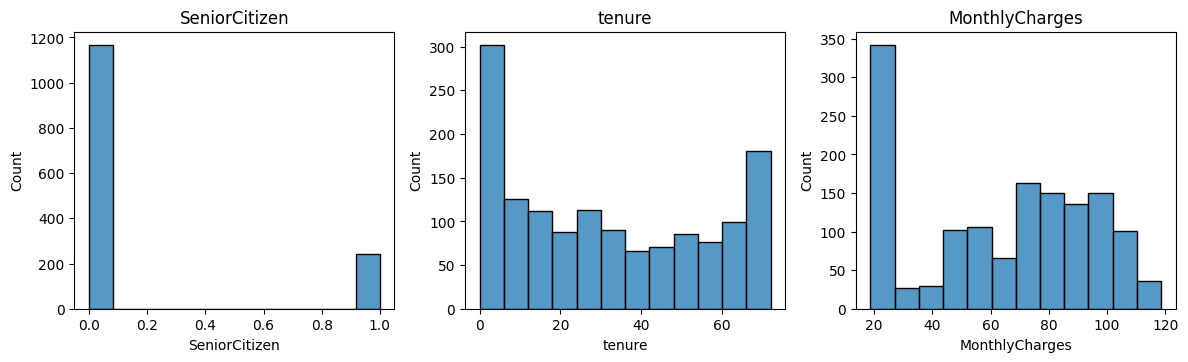

In [ ]:
# drawing the histplot

num_col = ['SeniorCitizen','tenure','MonthlyCharges', ]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.histplot(data=test_df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_col), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

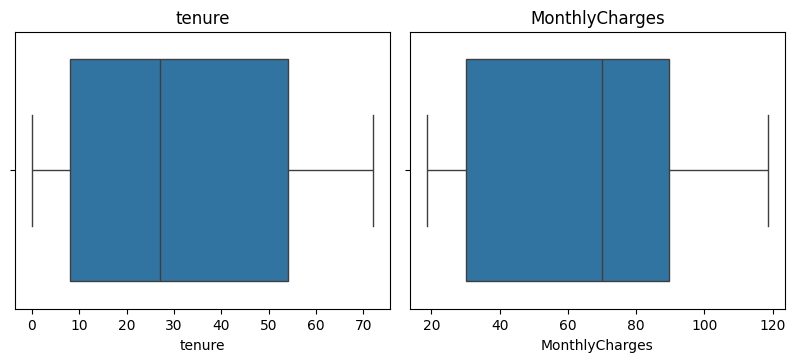

In [ ]:
# drawing the boxplot

num_col = ['tenure','MonthlyCharges', ]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.boxplot(data=test_df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_col), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

2.Data Preprocessing:

In [ ]:
# handling the missing values

# filling the na values using median
test_df['TotalCharges'] = test_df['TotalCharges'].fillna(test_df['TotalCharges'].median())


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Define feature columns
cols_with_special_values = ['MultipleLines', 'OnlineBackup', 'DeviceProtection',
                            'TechSupport', 'StreamingTV', 'StreamingMovies','OnlineSecurity']
other_binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling','gender']
onehot_cols = ['InternetService', 'Contract', 'PaymentMethod']

ordinal_encode_cols = other_binary_cols + cols_with_special_values

# Step 1: Clean special values
test_df[cols_with_special_values] = test_df[cols_with_special_values].replace({
    'No internet service': 'No',
    'No phone service': 'No'
})

# Step 2: Ordinal Encoding (Binary & Special columns)
ord_encoder = OrdinalEncoder(dtype=int)
test_df[ordinal_encode_cols] = ord_encoder.fit_transform(test_df[ordinal_encode_cols])

# Step 3: One-Hot Encoding (Multi-category columns)
# Note: drop='first' is kept here since there is no train/test splitting conflict
ohe_encoder = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe_encoder.fit_transform(test_df[onehot_cols])

# Create DataFrame with encoded column names
ohe_feature_names = ohe_encoder.get_feature_names_out(onehot_cols)
ohe_df = pd.DataFrame(ohe_array, columns=ohe_feature_names, index=test_df.index)

# Step 4: Combine all columns
test_df = pd.concat([test_df.drop(columns=onehot_cols), ohe_df], axis=1)

print("Processed DataFrame Shape:", test_df.shape)

Processed DataFrame Shape: (1409, 25)


In [ ]:
test_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,6080-TCMYC,1,0,1,1,40,1,1,0,0,...,81.20,3292.30,No,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,7285-KLOTR,0,0,1,0,12,1,1,1,0,...,78.85,876.75,No,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7486-KSRVI,1,0,0,0,43,1,1,0,0,...,100.00,4211.55,Yes,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,9924-JPRMC,1,0,0,0,72,1,1,1,1,...,118.20,8547.15,No,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,4439-YRNVD,0,0,0,0,10,0,0,0,1,...,36.25,374.00,No,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,2039-JONDJ,1,0,0,0,27,1,0,1,1,...,55.45,1477.65,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1405,2516-VQRRV,0,1,0,0,2,1,1,0,0,...,75.45,158.40,Yes,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1406,5570-PTWEH,0,0,1,0,3,1,1,0,0,...,75.15,216.75,Yes,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1407,1722-LDZJS,1,0,1,1,53,1,0,0,0,...,20.20,1068.15,No,0.0,1.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
# scailing the data

num_col = ['TotalCharges','tenure','MonthlyCharges']

from sklearn.preprocessing import MinMaxScaler

scalar = MinMaxScaler()

# Scale numerical columns for x_train
test_df[num_col] = scalar.fit_transform(test_df[num_col])


In [ ]:
test_df['CLV_Estimated'] = test_df['tenure'] * test_df['MonthlyCharges']

In [ ]:
test_df = test_df.drop(columns=['Churn','customerID'])

In [ ]:
test_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CLV_Estimated
0,1,0,1,1,0.555556,1,1,0,0,1,...,0.625626,0.383837,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.347570
1,0,0,1,0,0.166667,1,1,1,0,1,...,0.602102,0.100600,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.100350
2,1,0,0,0,0.597222,1,1,0,0,0,...,0.813814,0.491625,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.486028
3,1,0,0,0,1.000000,1,1,1,1,1,...,0.995996,1.000000,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.995996
4,0,0,0,0,0.138889,0,0,0,1,0,...,0.175676,0.041649,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.024399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,1,0,0,0,0.375000,1,0,1,1,0,...,0.367868,0.171059,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.137950
1405,0,1,0,0,0.027778,1,1,0,0,0,...,0.568068,0.016369,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.015780
1406,0,0,1,0,0.041667,1,1,0,0,0,...,0.565065,0.023211,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.023544
1407,1,0,1,1,0.736111,1,0,0,0,0,...,0.015015,0.123043,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.011053


In [ ]:
from sklearn.decomposition import PCA

test_df = pca_applied.transform(test_df) # Use the existing and correctly fitted pca_applied object.

test_df= pd.DataFrame(test_df,columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])

Checking the Model


In [ ]:
x_test.shape

(1409, 10)

In [ ]:
test_df.shape

(1409, 10)

In [ ]:
# checking the random forest classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

rfc = RandomForestClassifier(n_estimators = 10, min_samples_split = 15,
                             min_samples_leaf = 4, max_features = 'sqrt',
                             max_depth = 5, criterion = 'entropy')
rfc.fit(x_train,y_train)
y_pred_rfc = rfc.predict(test_df)

print("Accuracy:", accuracy_score(y_test, y_pred_rfc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rfc))

Accuracy: 0.6366217175301633
Confusion Matrix:
 [[830 203]
 [309  67]]


In [ ]:
# checking for logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

lg = LogisticRegression(tol = 0.0001, solver = 'liblinear',
                        intercept_scaling = 7, class_weight = None, C = 10)
lg.fit(x_train,y_train)
y_pred_lg = lg.predict(test_df)

print("Accuracy:", accuracy_score(y_test, y_pred_lg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lg))

Accuracy: 0.6373314407381121
Confusion Matrix:
 [[832 201]
 [310  66]]


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=20,
    random_state=42,
    eval_metric='logloss',
    max_leaves = 4,
)

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(test_df)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.6337828246983677
Confusion Matrix:
 [[826 207]
 [309  67]]


Conclusion & RecommendationsKey Findings:   
Contract Type & Onboarding: High churn is concentrated among customers on short-term Month-to-Month plans during their first 12 months.Pricing Sensitivity: Customers paying above $\$70/\text{month}$ display a higher risk of departure if they do not hold long-term contracts or security add-ons.   

Business Recommendations:  
Contract Conversion Incentives: Offer small discounts or fee waivers to transition short-term month-to-month customers onto 1-year or 2-year contracts.Early Retainership Campaigns: Trigger proactive customer success outreach and onboarding surveys within the first 90 days of continuous service.Targeted Interventions: Deploy the tuned Gradient Boosting model to identify top high-risk churn candidates monthly and target them with specialized retention packages.